In [ ]:
%load_ext autoreload
%autoreload 2

import deepxde as dde
import numpy as np
from config import MU_HEAT, NX_HEAT, NT_HEAT, L_HEAT, T_HEAT, ALPHA

dde.config.set_default_float("float64")

# Generación del dominio (no hay puntos)
geom = dde.geometry.Interval(0, L_HEAT)                   # Parte espacial
timedomain = dde.geometry.TimeDomain(0, T_HEAT)           # Parte temporal
geomtime = dde.geometry.GeometryXTime(geom, timedomain)   # Dominio espaciotemporal

def pde_calor(x, u):
    """
    Residuo de la ecuación del calor: u_t - alpha * u_xx = 0
    x: tensor con las coordenadas (columna 0 = posición espacial, columna 1 = tiempo)
    u: salida de la red evaluada en esos puntos
    """
    u_t = dde.grad.jacobian(u, x, i=0, j=1)    # i: columna de la salida "u" (solo hay una en nuestras PINNs)
    u_xx = dde.grad.hessian(u, x, i=0, j=0)    # j: columna de x para derivar "u" (en este caso j=0 --> espacial)
    return u_t - ALPHA * u_xx

def condicion_inicial_calor(x):
    return np.sin(2 * np.pi * x[:, 0:1] / L_HEAT)

# La condición inicial completa
ic = dde.icbc.IC(
    geomtime,
    condicion_inicial_calor,
    lambda x, on_initial: on_initial    # Para que DeepXDE aplique esta condición a los puntos de t=0
)

# Condiciones de contorno

bc_valores = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,
    component=0,
    on_boundary=lambda x, on_boundary: on_boundary
    # sin derivative_order: por defecto exige igualdad de VALORES, u(0,t)=u(L,t)
)

bc_derivadas = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,                                     # Sobre que variable de entrada se impone la periodicidad (espacial)
    component=0,                                       # Sobre que salida de la red se aplica la condición (solo hay una)
    on_boundary=lambda x, on_boundary: on_boundary,    # Para que DeepXDE aplique esta condición a los puntos del  contorno espacial
    derivative_order=1                                 # Para que las derivadas también cumplan que se igualan en los extremos
    # con derivative_order=1: exige igualdad de DERIVADAS, u_x(0,t)=u_x(L,t)
)

# Juntar los datos del problema
data = dde.data.TimePDE(
    geomtime,            # El dominio del paso 1
    pde_calor,           # El residuo del paso 2
    [ic, bc_valores, bc_derivadas],            # Las condiciones del paso 3, en una lista
    num_domain=5000,     # N_f: puntos de colocación en el interior, para L_edp
    num_initial=400,     # N_0: puntos en t=0, para L_ic
    num_boundary=400     # N_b: puntos en x=0 y x=L, para L_bc
)

# Red neuronal
capas = [2] + [50] * 4 + [1]
activacion = "tanh"
inicializador = "Glorot uniform"    # Forma en la queu la red asigna unos pesos iniciales a cada neurona

red = dde.nn.FNN(capas, activacion, inicializador)

# Indicar que la red va a ser entrenada con "data"
model = dde.Model(data, red)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# Primera fase del entrenaiento de la red con optimizdor Adam
model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=15000)

Compiling model...
'compile' took 1.639730 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.27e-02, 4.39e-01, 3.12e-01, 5.41e-02]    [4.27e-02, 4.39e-01, 3.12e-01, 5.41e-02]    []  


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [3.09e-03, 2.77e-04, 7.03e-04, 2.90e-04]    [3.09e-03, 2.77e-04, 7.03e-04, 2.90e-04]    []  
2000      [5.53e-04, 5.16e-05, 4.27e-05, 9.08e-06]    [5.53e-04, 5.16e-05, 4.27e-05, 9.08e-06]    []  
3000      [2.23e-04, 3.52e-05, 1.89e-05, 7.46e-06]    [2.23e-04, 3.52e-05, 1.89e-05, 7.46e-06]    []  
4000      [1.21e-04, 2.70e-05, 1.37e-05, 5.33e-06]    [1.21e-04, 2.70e-05, 1.37e-05, 5.33e-06]    []  
5000      [1.15e-04, 6.34e-05, 9.30e-06, 9.18e-04]    [1.15e-04, 6.34e-05, 9.30e-06, 9.18e-04]    []  
6000      [6.25e-05, 1.64e-05, 8.01e-06, 2.53e-06]    [6.25e-05, 1.64e-05, 8.01e-06, 2.53e-06]    []  
7000      [4.97e-05, 1.30e-05, 6.53e-06, 1.75e-06]    [4.97e-05, 1.30e-05, 6.53e-06, 1.75e-06]    []  
8000      [4.09e-05, 1.04e-05, 5.37e-06, 1.20e-06]    [4.09e-05, 1.04e-05, 5.37e-06, 1.20e-06]    []  
9000      [4.16e-05, 4.79e-05, 6.47e-05, 1.33e-04]    [4.16e-05, 4.79e-05, 6.47e-05, 1.33e-04]    []  
10000     [3.02e-05, 7.55e-06, 3.79e-06, 5.80e-07]    [3.02e-05, 7.55e-06

In [ ]:
# Segunda fase del entrenaiento de la red con optimizdor L-BFGS
dde.optimizers.config.set_LBFGS_options(maxiter=10000, ftol=1e-14, gtol=1e-12)

model.compile("L-BFGS")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.001002 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
15000     [1.87e-05, 4.00e-06, 1.65e-06, 1.09e-07]    [1.87e-05, 4.00e-06, 1.65e-06, 1.09e-07]    []  
15006     [1.87e-05, 4.00e-06, 1.65e-06, 1.09e-07]    [1.87e-05, 4.00e-06, 1.65e-06, 1.09e-07]    []  

Best model at step 15006:
  train loss: 2.45e-05
  test loss: 2.45e-05
  test metric: []

'train' took 0.398514 s



In [ ]:
import matplotlib.pyplot as plt

# Cargar datos de FDM para el calor
datos_fdm = np.load('heat_fdm_resultado.npz')
x_eval = datos_fdm['x']                         # Puntos de evaluación
u_fdm_final = datos_fdm['u_fdm_final']          # Salida u de la FDM
u_exacta = datos_fdm['u_exacta']                # Salida u de la expresión analítica exacta

# Evaluar la PINN en los mismos puntos de FDM para poder comparar
t_eval = np.full_like(x_eval, T_HEAT)
puntos_eval = np.vstack((x_eval, t_eval)).T
u_pinn = model.predict(puntos_eval).flatten()

# Cálculo de errores
error_l2_fdm = np.linalg.norm(u_fdm_final - u_exacta) / np.linalg.norm(u_exacta)
error_l2_pinn = np.linalg.norm(u_pinn - u_exacta) / np.linalg.norm(u_exacta)
print("Error L2 relativo (FDM):", error_l2_fdm)
print("Error L2 relativo (PINN):", error_l2_pinn)

# Condición inicial
u0 = np.sin(2 * np.pi * x_eval / L_HEAT)

# Gráfica comparativa
plt.figure(figsize=(8, 5))
plt.plot(x_eval, u0, '--', label='Condición inicial (t=0)', color='gray')
plt.plot(x_eval, u_fdm_final, 'o-', label='FDM (t=T)', markersize=3)
plt.plot(x_eval, u_pinn, 's-', label='PINN (t=T)', markersize=3)
plt.plot(x_eval, u_exacta, '-', label='Analítica (t=T)')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — FDM vs. PINN vs. Solución Analítica')
plt.show()

NameError: name 'model' is not defined

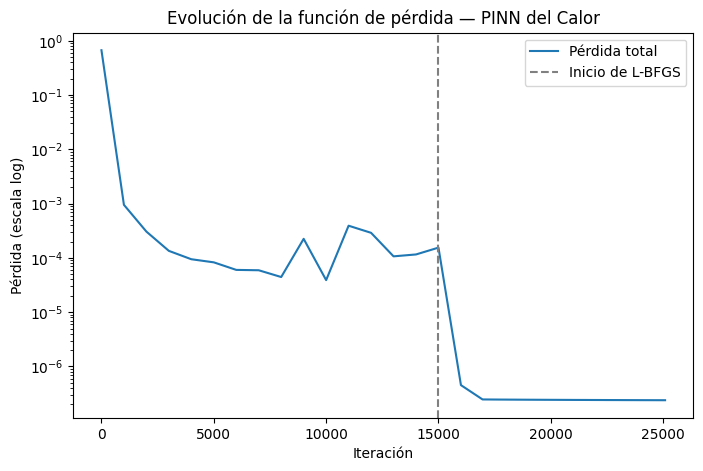

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- Sumar los 4 términos de la pérdida en cada paso, para tener un único "total" ---
loss_total = np.sum(losshistory.loss_train, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(losshistory.steps, loss_total, label='Pérdida total')
plt.axvline(x=15000, color='gray', linestyle='--', label='Inicio de L-BFGS')
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (escala log)')
plt.legend()
plt.title('Evolución de la función de pérdida — PINN del Calor')
plt.show()

In [17]:
# Guardado de los datos
np.savez('heat_pinn_resultado.npz', x=x_eval, u_pinn=u_pinn, error_l2_pinn=error_l2_pinn, loss_steps=losshistory.steps, loss_total=loss_total)